<a href="https://colab.research.google.com/github/Zafeer-Sultan/Portfolio/blob/main/Coin_geko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Libraries
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# STEP 1: Fetch Bitcoin data
import requests
import pandas as pd

def fetch_crypto_data(coin='bitcoin', currency='usd', days=120):
    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"
    params = {
        'vs_currency': currency,
        'days': days,
        'interval': 'daily'
    }
    response = requests.get(url, params=params)
    data = response.json()
    df = pd.DataFrame(data['prices'], columns=['timestamp', 'price'])
    df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
    return df[['date', 'price']]

btc_df = fetch_crypto_data(days=180)
btc_df.head()

,date,price
0,2024-11-22,98509.118591
1,2024-11-23,98927.494946
2,2024-11-24,97679.463816
3,2024-11-25,98015.935529
4,2024-11-26,93004.700931


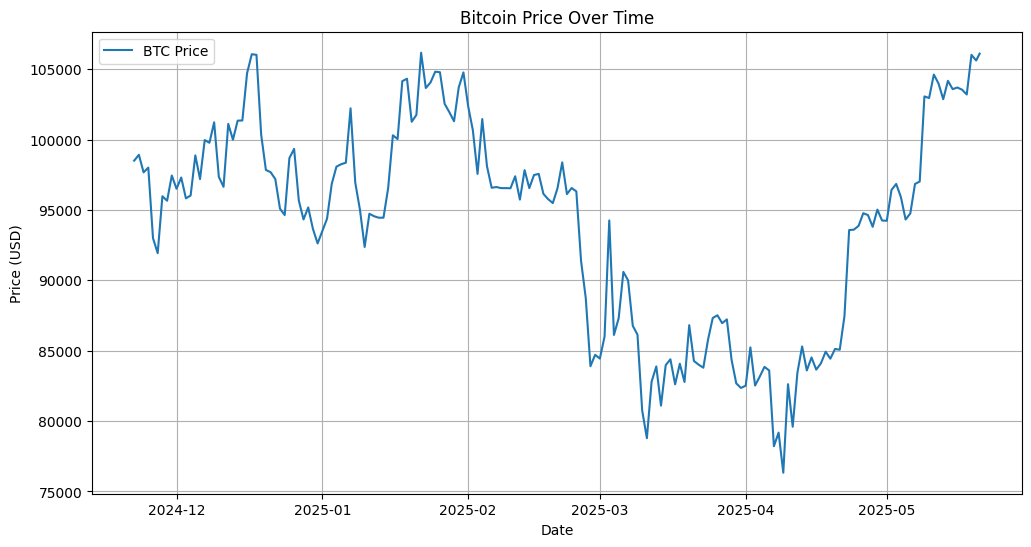

In [ ]:
import matplotlib.pyplot as plt

# Line chart
plt.figure(figsize=(12,6))
plt.plot(btc_df['date'], btc_df['price'], label='BTC Price')
plt.title("Bitcoin Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


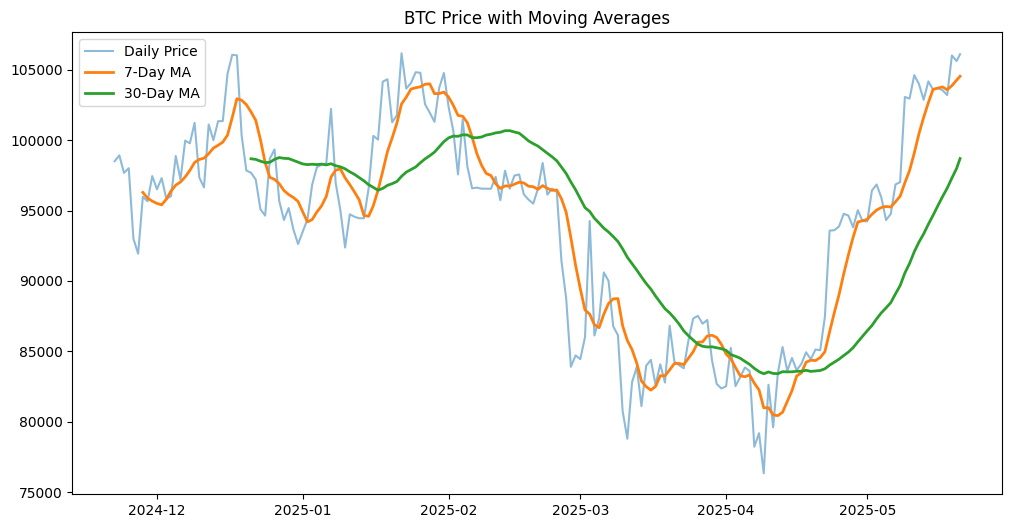

In [ ]:
btc_df['price_7day_avg'] = btc_df['price'].rolling(window=7).mean()
btc_df['price_30day_avg'] = btc_df['price'].rolling(window=30).mean()

plt.figure(figsize=(12, 6))
plt.plot(btc_df['date'], btc_df['price'], label='Daily Price', alpha=0.5)
plt.plot(btc_df['date'], btc_df['price_7day_avg'], label='7-Day MA', linewidth=2)
plt.plot(btc_df['date'], btc_df['price_30day_avg'], label='30-Day MA', linewidth=2)
plt.title("BTC Price with Moving Averages")
plt.legend()
plt.show()


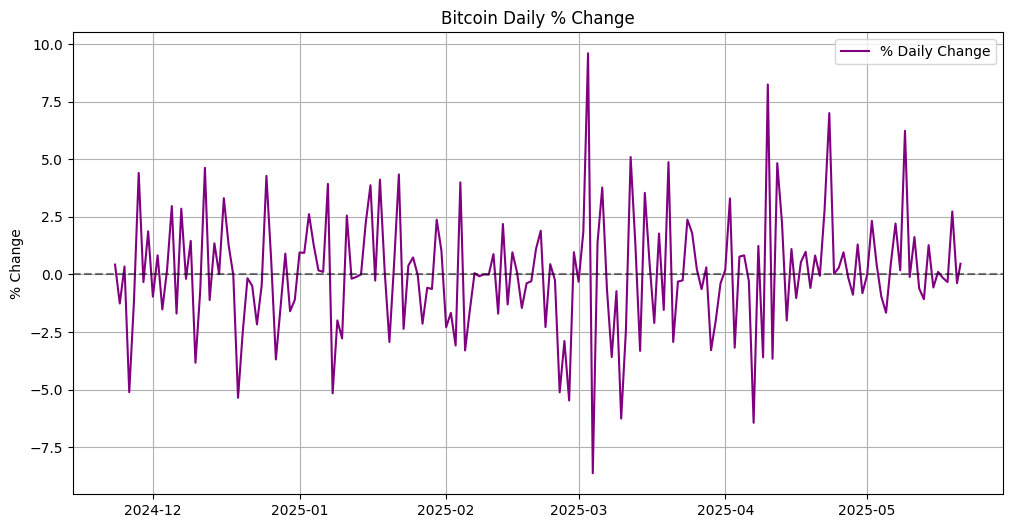

In [ ]:
btc_df['pct_change'] = btc_df['price'].pct_change() * 100

plt.figure(figsize=(12, 6))
plt.plot(btc_df['date'], btc_df['pct_change'], label='% Daily Change', color='purple')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Bitcoin Daily % Change")
plt.ylabel("% Change")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# 3. Data Preprocessing & Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
btc_scaled = scaler.fit_transform(btc_df[['price']])


In [ ]:
# 4. Create Sequences for LSTM (e.g., past 30 days -> predict next day)
def create_sequences(data, seq_length=30):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

SEQ_LENGTH = 30
X, y = create_sequences(btc_scaled, SEQ_LENGTH)

In [ ]:
# Reshape X for LSTM input (samples, timesteps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 5. Train-Test Split (80% train)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
# 6. Build Stacked LSTM Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# 7. Train the Model with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), callbacks=[early_stop])

# 8. Predictions & Evaluation
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
actuals = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - loss: 0.2570 - val_loss: 0.1608
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0397 - val_loss: 0.0108
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0737 - val_loss: 0.0387
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0295 - val_loss: 0.0943
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0301 - val_loss: 0.1022
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0264 - val_loss: 0.0697
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0243 - val_loss: 0.0391
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0260 - val_loss: 0.0313
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0236 - val_loss: 0.0404
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0174 - val_loss: 0.0553
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0230 - val_loss: 0.0619
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0205 - val_loss: 0.0526


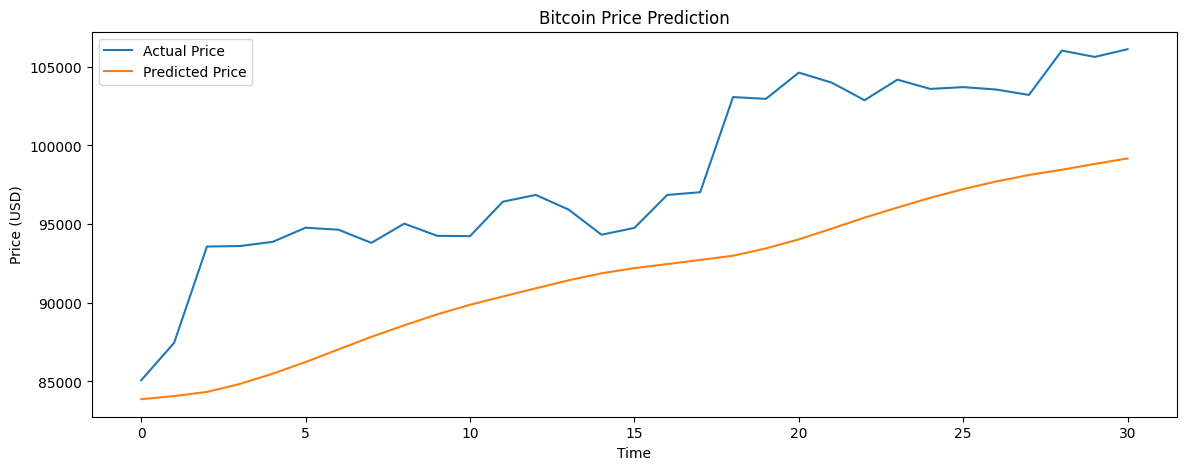

In [ ]:
# 9. Plot Actual vs Predicted Prices
plt.figure(figsize=(14,5))
plt.plot(actuals, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title('Bitcoin Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [ ]:
# 10. Save model and scaler for future use (optional)
model.save('bitcoin_lstm_model.h5')
import joblib
joblib.dump(scaler, 'scaler.save')

['scaler.save']